<a href="https://colab.research.google.com/github/Ewha-Euron/10th-ML/blob/week_11/%EB%B3%B5%EC%8A%B5%EB%AC%B8%EC%A0%9C_11%EC%A3%BC%EC%B0%A8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 11주차 복습과제: 군집화

다음은 11주차 군집화 세션의 복습과제입니다. 문제 조건에 맞춰 코드를 작성하고, 설명을 추가해 주세요.

---

#Section A: 군집화, K-means

문제 1: 좋은 군집화란?

좋은 군집화의 조건을 설명하시오.

**요구 사항**

군집 내부 응집도(Within-cluster similarity)의 의미를 설명하시오.

군집 간 분리도(Between-cluster dissimilarity)의 의미를 설명하시오.



**답안**

좋은 군집화란 같은 군집 안의 데이터들은 서로 최대한 비슷하고, 서로 다른 군집에 속한 데이터들은 최대한 다르게 나뉘는 것을 의미한다.

- **군집 내부 응집도(Within-cluster similarity)**: 하나의 군집 안에 있는 데이터들이 서로 얼마나 유사한지를 의미한다. 좋은 군집화에서는 같은 군집에 속한 데이터들의 거리나 차이가 작아야 하며, 즉 군집 내부 데이터들이 조밀하게 모여 있어야 한다.
- **군집 간 분리도(Between-cluster dissimilarity)**: 서로 다른 군집들이 얼마나 잘 구분되는지를 의미한다. 좋은 군집화에서는 군집과 군집 사이의 거리가 충분히 멀어야 하며, 서로 다른 군집의 데이터가 섞이지 않고 명확히 분리되어야 한다.

따라서 좋은 군집화는 **군집 내부 응집도는 높고, 군집 간 분리도는 높은 상태**라고 할 수 있다.


문제 2: K-Means에서 군집 개수 K는 매우 중요한 파라미터이다.
동일한 데이터에 대해 서로 다른 K값을 적용했을 때 군집화 결과가 어떻게 달라지는지 비교하시오.

데이터 생성 조건
샘플 수 : 400개
군집 수 : 4개
특징 수 : 2개
random_state : 0
수행 조건

다음 K값에 대해 각각 군집화를 수행하시오.

Case 1 : K = 2
Case 2 : K = 4
Case 3 : K = 6
(배운 파라미터를 기반으로 작성하면 됨)

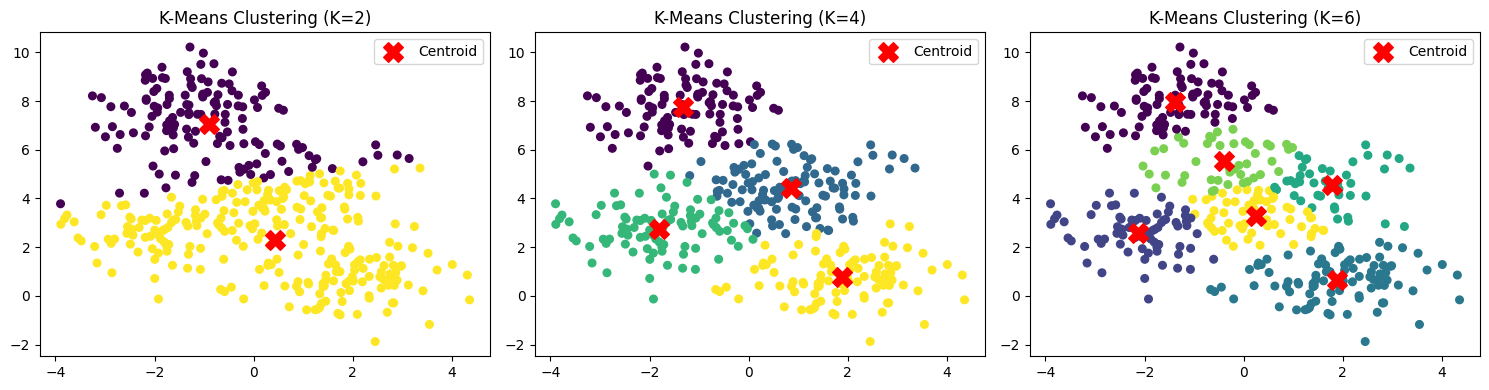

K=2: 실제 군집 수보다 작아 서로 다른 군집들이 하나로 합쳐진다.
K=4: 데이터 생성 조건의 실제 군집 수와 같아 가장 자연스럽게 분리된다.
K=6: 실제 군집 수보다 커서 하나의 자연스러운 군집이 여러 개로 쪼개질 수 있다.


In [1]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=400,
    centers=4,
    n_features=2,
    random_state=0
)

k_values = [2, 4, 6]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, k in zip(axes, k_values):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
    ax.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        c='red',
        marker='X',
        s=200,
        label='Centroid'
    )
    ax.set_title(f'K-Means Clustering (K={k})')
    ax.legend()

plt.tight_layout()
plt.show()

print("K=2: 실제 군집 수보다 작아 서로 다른 군집들이 하나로 합쳐진다.")
print("K=4: 데이터 생성 조건의 실제 군집 수와 같아 가장 자연스럽게 분리된다.")
print("K=6: 실제 군집 수보다 커서 하나의 자연스러운 군집이 여러 개로 쪼개질 수 있다.")


문제 3 : Elbow Method - 최적 K찾기

K-Means는 사전에 K값을 지정해야 하기 때문에 적절한 군집 개수를 선택하는 과정이 중요하다. Elbow Method를 사용하여 최적의 군집 수를 탐색하시오. 데이터 생성 조건 샘플 수 : 500개 군집 수 : 5개 특징 수 : 2개 random_state : 10

수행 조건 K를 1부터 10까지 변화시키며 K-Means 수행

K값에 따른 SSE 그래프를 그리시오.

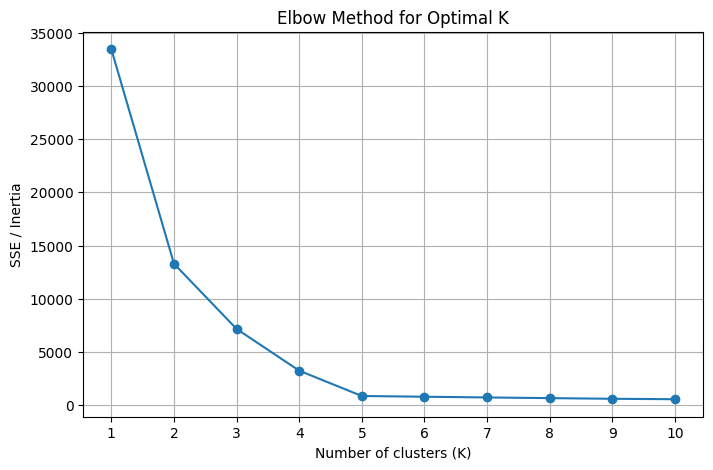

SSE는 K가 증가할수록 감소한다.
그래프에서 감소 폭이 급격하다가 완만해지는 지점, 즉 팔꿈치처럼 꺾이는 지점이 최적 K이다.
이 데이터는 centers=5로 생성되었기 때문에 K=5 부근이 적절한 군집 수로 해석된다.


In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=500,
    centers=5,
    n_features=2,
    random_state=10
)

# K-means 수행 및 SSE 저장
sse = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# SSE 그래프 시각화
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE / Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("SSE는 K가 증가할수록 감소한다.")
print("그래프에서 감소 폭이 급격하다가 완만해지는 지점, 즉 팔꿈치처럼 꺾이는 지점이 최적 K이다.")
print("이 데이터는 centers=5로 생성되었기 때문에 K=5 부근이 적절한 군집 수로 해석된다.")


문제 4: make_blobs를 이용해 2차원 데이터를 생성하고,
K=3으로 K-Means 군집화를 수행하시오.

centroid를 함께 시각화할 것
random_state=42 사용

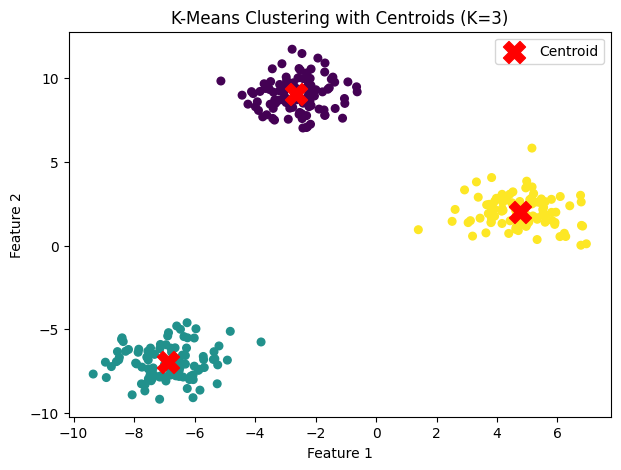

Centroids:
[[-2.63323268  9.04356978]
 [-6.88387179 -6.98398415]
 [ 4.74710337  2.01059427]]


In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    random_state=42
)

# K-Means 군집화
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    marker='X',
    s=250,
    label='Centroid'
)
plt.title('K-Means Clustering with Centroids (K=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

print("Centroids:")
print(centers)


문제 5:
iris 데이터셋에 대해
K=2
K=8로 각각 K-Means 군집화를 수행하고 결과를 시각화하시오.


이를 통해
K가 너무 작을 때의 문제점
K가 너무 클 때의 문제점을 서술하시오.

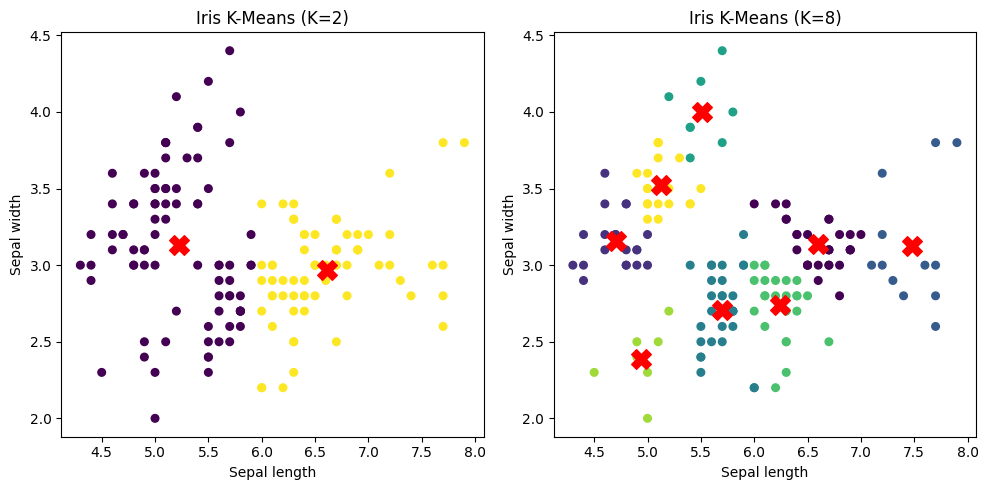

In [5]:
# iris data 불러오기
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# iris 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]   # 앞 2개 feature만 사용

# subplot 생성
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# K=2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X)

axes[0].scatter(X[:, 0], X[:, 1], c=labels_2, cmap='viridis', s=30)
axes[0].scatter(
    kmeans_2.cluster_centers_[:, 0],
    kmeans_2.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200
)
axes[0].set_title('Iris K-Means (K=2)')
axes[0].set_xlabel('Sepal length')
axes[0].set_ylabel('Sepal width')

# K=8
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init=10)
labels_8 = kmeans_8.fit_predict(X)

axes[1].scatter(X[:, 0], X[:, 1], c=labels_8, cmap='viridis', s=30)
axes[1].scatter(
    kmeans_8.cluster_centers_[:, 0],
    kmeans_8.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=200
)
axes[1].set_title('Iris K-Means (K=8)')
axes[1].set_xlabel('Sepal length')
axes[1].set_ylabel('Sepal width')

plt.tight_layout()
plt.show()

**답안**

K가 너무 작으면 서로 다른 특성을 가진 데이터들이 같은 군집으로 묶이게 된다. 이 경우 데이터의 실제 구조를 충분히 반영하지 못하고, 군집 간 차이가 흐려진다.

반대로 K가 너무 크면 하나의 자연스러운 군집이 여러 개로 잘게 나뉘게 된다. 이 경우 의미 있는 군집이라기보다 데이터의 작은 차이까지 과도하게 반영하는 결과가 나타날 수 있다.

따라서 K는 너무 작지도, 너무 크지도 않게 데이터의 구조를 잘 설명할 수 있는 값으로 설정해야 한다.


문제 6:

실루엣 계수(Silhouette Score)가 무엇인지 간단히 설명하시오.

실루엣 계수가 1, 0, 음수에 가까울 때 각각 어떤 의미를 가지는지 설명하시오.

**답안**

실루엣 계수는 군집화 결과가 얼마나 잘 이루어졌는지를 평가하는 지표이다. 각 데이터가 자기 군집 안의 다른 데이터들과 얼마나 가깝고, 다른 군집의 데이터들과는 얼마나 멀리 떨어져 있는지를 함께 고려한다.

- **1에 가까울 때**: 같은 군집 안의 데이터와는 가깝고 다른 군집과는 멀리 떨어져 있어 군집화가 잘 된 상태이다.
- **0에 가까울 때**: 데이터가 두 군집의 경계 근처에 있어 어느 군집에 속하는지 애매한 상태이다.
- **음수에 가까울 때**: 데이터가 현재 속한 군집보다 다른 군집에 더 가까운 상태로, 잘못 군집화되었을 가능성이 크다.


문제 7:
iris 데이터셋에 대해 다음 조건으로 K-Means 군집화를 수행하시오.

**요구사항**

군집화를 수행하고 결과를 시각화하시오.

cluster_centers_를 출력하시오.

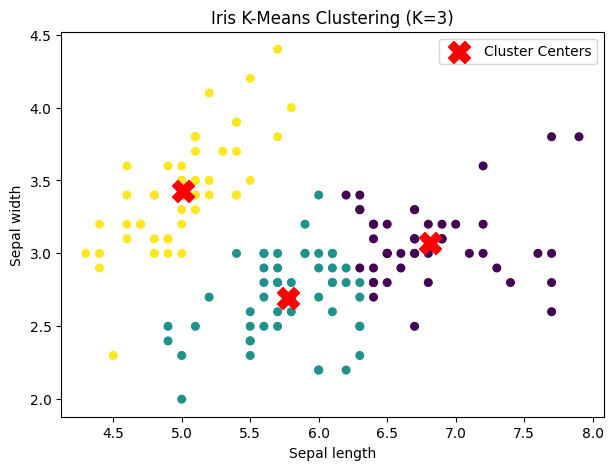

cluster_centers_:
[[6.81276596 3.07446809]
 [5.77358491 2.69245283]
 [5.006      3.428     ]]


In [6]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# iris 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]

# K-Means 모델 생성 및 학습
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

labels = kmeans.fit_predict(X)

# 결과 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    c='red',
    marker='X',
    s=250,
    label='Cluster Centers'
)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Iris K-Means Clustering (K=3)')
plt.legend()
plt.show()

# cluster_centers_ 출력
print("cluster_centers_:")
print(kmeans.cluster_centers_)


문제 8: 다음 파라미터들의 역할을 간단히 설명하시오.

n_clusters

init

n_init

max_iter

random_state

**답안**

- **n_clusters**: 생성할 군집의 개수, 즉 K 값을 의미한다.
- **init**: 초기 중심점(centroid)을 설정하는 방법이다. 일반적으로 `k-means++`를 사용하면 초기 중심점을 효율적으로 선택하여 안정적인 결과를 얻을 수 있다.
- **n_init**: 서로 다른 초기 중심점으로 K-Means를 몇 번 반복 실행할지 정하는 값이다. 여러 번 실행한 뒤 가장 좋은 결과를 선택한다.
- **max_iter**: 한 번의 K-Means 실행에서 중심점 갱신을 최대 몇 번까지 반복할지 정하는 값이다.
- **random_state**: 난수 고정값이다. 같은 결과를 재현하기 위해 사용한다.


### Section B: 평균 이동, GMM, DBSCAN

#### 문제 1: 평균 이동(Mean Shift) 군집화의 이해

Mean Shift 알고리즘은 KMeans와 유사하게 거리 기반 군집화 방법 중 하나입니다. 이 알고리즘의 동작 방식에 대해 간략히 설명하고, `make_blobs`를 사용하여 가상의 데이터셋을 생성한 후 `MeanShift`를 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

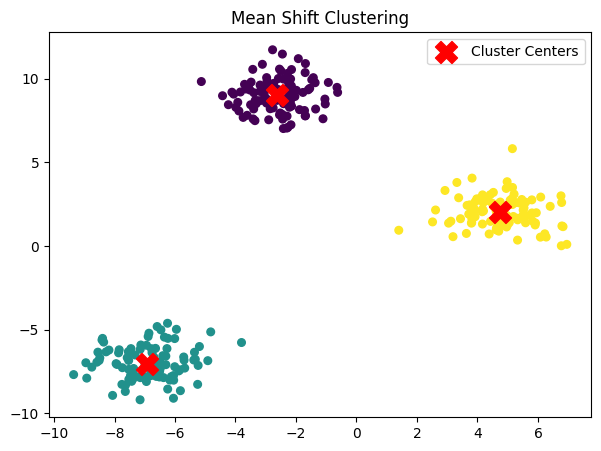

Mean Shift는 데이터가 밀집된 방향으로 중심점을 반복적으로 이동시키면서 군집 중심을 찾는 알고리즘이다.
K-Means와 달리 군집 개수를 사전에 지정하지 않아도 되며, bandwidth에 따라 군집 수가 결정된다.
추정된 bandwidth: 2.768429952284618
군집 개수: 3


In [7]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    random_state=42
)

# bandwidth 추정
bandwidth = estimate_bandwidth(X)

# Mean Shift 적용
meanshift = MeanShift(bandwidth=bandwidth)
labels = meanshift.fit_predict(X)
centers = meanshift.cluster_centers_

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    marker='X',
    s=250,
    label='Cluster Centers'
)
plt.title('Mean Shift Clustering')
plt.legend()
plt.show()

print("Mean Shift는 데이터가 밀집된 방향으로 중심점을 반복적으로 이동시키면서 군집 중심을 찾는 알고리즘이다.")
print("K-Means와 달리 군집 개수를 사전에 지정하지 않아도 되며, bandwidth에 따라 군집 수가 결정된다.")
print("추정된 bandwidth:", bandwidth)
print("군집 개수:", len(np.unique(labels)))


#### 문제 2: Mean Shift 군집화 파라미터 이해 및 조정

Mean Shift 알고리즘에서 `bandwidth` 파라미터는 군집화 결과에 큰 영향을 미칩니다. `bandwidth` 값을 다르게 설정했을 때 군집화 결과가 어떻게 달라지는지 확인하기 위해, 다음 조건을 따라 코드를 작성하고 결과를 비교하여 설명하세요.

**데이터 생성 조건:** (문제 1과 동일)
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**MeanShift 설정:**
- Case 1: `bandwidth`를 `estimate_bandwidth`로 추정한 값 사용
- Case 2: `bandwidth`를 추정값의 0.5배로 설정
- Case 3: `bandwidth`를 추정값의 2배로 설정

각 Case별로 군집화 결과를 시각화하고, 군집의 개수 변화와 그 이유를 간략하게 설명하세요.

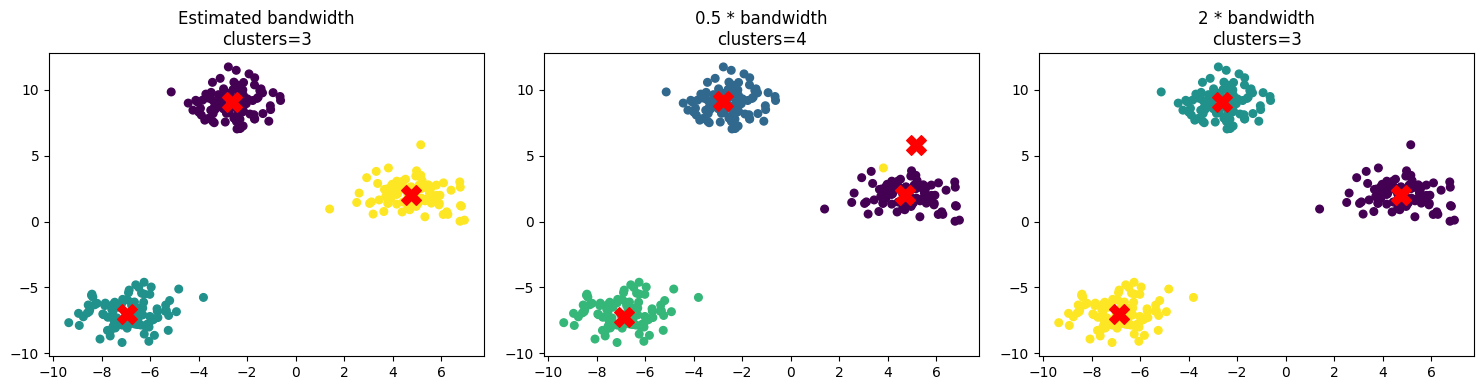

bandwidth는 Mean Shift에서 주변 데이터의 밀도를 탐색하는 반경 역할을 한다.
bandwidth가 작으면 좁은 범위만 탐색하므로 군집이 더 많이, 잘게 나뉠 수 있다.
bandwidth가 크면 넓은 범위를 하나의 밀도 영역으로 보기 때문에 군집 수가 줄어들 수 있다.


In [8]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    random_state=42
)

# bandwidth 추정
estimated_bw = estimate_bandwidth(X)

bandwidth_cases = {
    'Estimated bandwidth': estimated_bw,
    '0.5 * bandwidth': estimated_bw * 0.5,
    '2 * bandwidth': estimated_bw * 2
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, bw) in zip(axes, bandwidth_cases.items()):
    meanshift = MeanShift(bandwidth=bw)
    labels = meanshift.fit_predict(X)
    centers = meanshift.cluster_centers_

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
    ax.scatter(
        centers[:, 0],
        centers[:, 1],
        c='red',
        marker='X',
        s=200
    )
    ax.set_title(f'{title}\nclusters={len(np.unique(labels))}')

plt.tight_layout()
plt.show()

print("bandwidth는 Mean Shift에서 주변 데이터의 밀도를 탐색하는 반경 역할을 한다.")
print("bandwidth가 작으면 좁은 범위만 탐색하므로 군집이 더 많이, 잘게 나뉠 수 있다.")
print("bandwidth가 크면 넓은 범위를 하나의 밀도 영역으로 보기 때문에 군집 수가 줄어들 수 있다.")


#### 문제 3: GMM (Gaussian Mixture Model) 군집화 및 KMeans와의 차이점

GMM은 각 군집이 가우시안 분포를 따른다고 가정하는 확률 기반 군집화 알고리즘입니다. GMM의 기본적인 개념과 KMeans와의 주요 차이점을 설명하고, `make_blobs`로 생성된 데이터에 `GaussianMixture`를 적용하여 군집화를 수행하고 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 400개
- 군집 수: 2개
- 특징 수: 2개
- 랜덤 시드: 0
- `cluster_std`를 각각 `[1.0, 2.5]`로 설정하여 타원형 분포를 갖도록 합니다.

**GMM 설정:**
- 군집 수: 2개
- 공분산 타입: `full`
- 랜덤 시드: 0

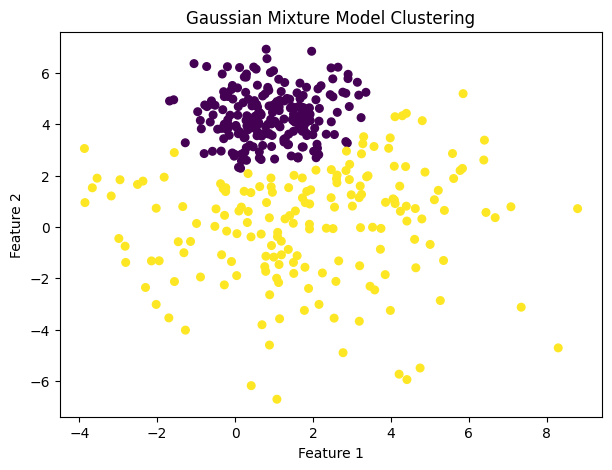

GMM은 각 군집이 가우시안 분포를 따른다고 가정하고, 각 데이터가 특정 군집에 속할 확률을 계산하는 확률 기반 군집화 알고리즘이다.
KMeans는 거리 기반으로 가장 가까운 중심점에 데이터를 할당하며 군집을 원형에 가깝게 나누는 경향이 있다.
반면 GMM은 평균과 공분산을 함께 고려하므로 타원형 분포나 군집의 퍼짐 정도가 다른 데이터에도 더 유연하게 적용할 수 있다.


In [9]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=400,
    centers=2,
    n_features=2,
    cluster_std=[1.0, 2.5],
    random_state=0
)

# GMM 적용
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=0
)

labels = gmm.fit_predict(X)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

print("GMM은 각 군집이 가우시안 분포를 따른다고 가정하고, 각 데이터가 특정 군집에 속할 확률을 계산하는 확률 기반 군집화 알고리즘이다.")
print("KMeans는 거리 기반으로 가장 가까운 중심점에 데이터를 할당하며 군집을 원형에 가깝게 나누는 경향이 있다.")
print("반면 GMM은 평균과 공분산을 함께 고려하므로 타원형 분포나 군집의 퍼짐 정도가 다른 데이터에도 더 유연하게 적용할 수 있다.")


#### 문제 4: DBSCAN (밀도 기반 군집화) 알고리즘 적용

DBSCAN은 밀도 기반 군집화 방법으로, 군집의 개수를 미리 지정할 필요가 없으며 다양한 형태의 군집을 찾을 수 있습니다. DBSCAN의 주요 파라미터(`eps`, `min_samples`)와 데이터 포인트의 세 가지 유형(`Core`, `Border`, `Noise`)에 대해 설명하고, `make_moons`를 사용하여 초승달 모양 데이터셋을 생성한 후 `DBSCAN`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 200개
- 노이즈 비율: 0.05
- 랜덤 시드: 42

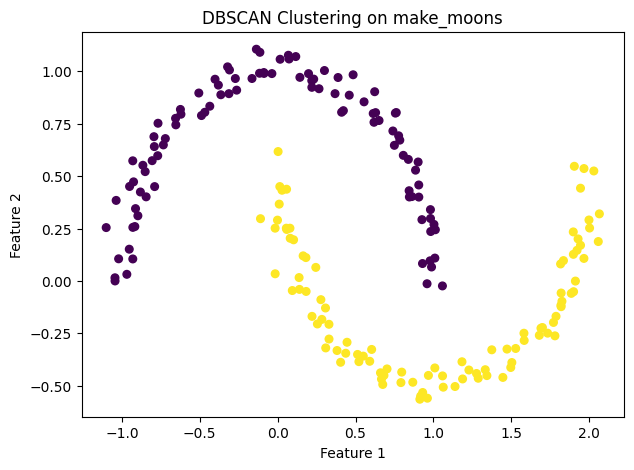

DBSCAN은 밀도가 높은 영역을 하나의 군집으로 묶는 밀도 기반 군집화 알고리즘이다.
eps: 한 데이터 포인트를 기준으로 이웃으로 인정할 거리 반경이다.
min_samples: eps 반경 안에 있어야 하는 최소 데이터 개수이다.
Core point: eps 반경 안에 min_samples 이상의 데이터가 있는 핵심 포인트이다.
Border point: Core point의 이웃이지만 자기 주변에는 min_samples만큼의 데이터가 없는 경계 포인트이다.
Noise point: 어떤 군집에도 속하지 않는 이상치 또는 잡음 포인트이며, label은 -1로 표시된다.
DBSCAN은 K를 미리 지정하지 않아도 되고, 초승달 모양처럼 비선형적인 형태의 군집도 잘 찾을 수 있다.
군집 라벨: [0 1]


In [10]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np

# 데이터 생성
X, y = make_moons(
    n_samples=200,
    noise=0.05,
    random_state=42
)

# DBSCAN 적용
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=30)
plt.title('DBSCAN Clustering on make_moons')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

print("DBSCAN은 밀도가 높은 영역을 하나의 군집으로 묶는 밀도 기반 군집화 알고리즘이다.")
print("eps: 한 데이터 포인트를 기준으로 이웃으로 인정할 거리 반경이다.")
print("min_samples: eps 반경 안에 있어야 하는 최소 데이터 개수이다.")
print("Core point: eps 반경 안에 min_samples 이상의 데이터가 있는 핵심 포인트이다.")
print("Border point: Core point의 이웃이지만 자기 주변에는 min_samples만큼의 데이터가 없는 경계 포인트이다.")
print("Noise point: 어떤 군집에도 속하지 않는 이상치 또는 잡음 포인트이며, label은 -1로 표시된다.")
print("DBSCAN은 K를 미리 지정하지 않아도 되고, 초승달 모양처럼 비선형적인 형태의 군집도 잘 찾을 수 있다.")
print("군집 라벨:", np.unique(labels))


### Section C: 병합 군집, 계층적 군집, 고객 세그먼테이션 (RFM)

#### 문제 5: 계층적 군집화 (Agglomerative Clustering)의 이해

계층적 군집화는 데이터를 계층적으로 묶어 트리 형태(덴드로그램)의 구조를 만듭니다. 이 중 병합 군집(Agglomerative Clustering)의 개념에 대해 설명하고, `make_blobs`로 생성된 간단한 데이터셋에 `AgglomerativeClustering`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: `ward`

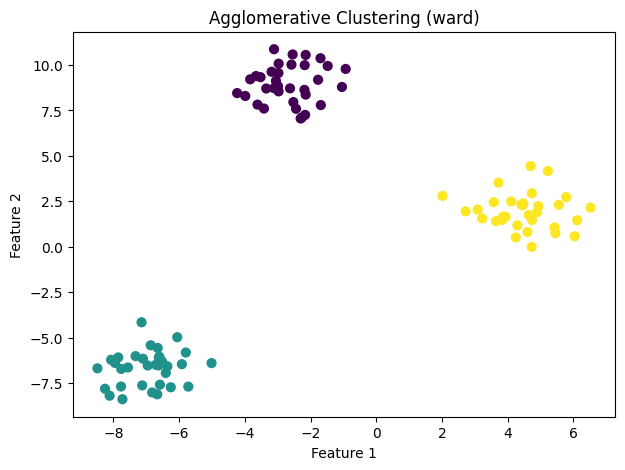

병합 군집화는 처음에는 각 데이터를 하나의 군집으로 보고, 가장 가까운 군집들을 차례대로 합쳐가며 계층적 구조를 만드는 방법이다.
이 과정을 통해 데이터가 어떤 순서와 구조로 묶이는지 파악할 수 있으며, 덴드로그램으로 표현할 수 있다.


In [11]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=100,
    centers=3,
    n_features=2,
    random_state=42
)

# Agglomerative Clustering 적용
agg = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

labels = agg.fit_predict(X)

# 시각화
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40)
plt.title('Agglomerative Clustering (ward)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

print("병합 군집화는 처음에는 각 데이터를 하나의 군집으로 보고, 가장 가까운 군집들을 차례대로 합쳐가며 계층적 구조를 만드는 방법이다.")
print("이 과정을 통해 데이터가 어떤 순서와 구조로 묶이는지 파악할 수 있으며, 덴드로그램으로 표현할 수 있다.")


#### 문제 6: 계층적 군집화의 Linkage 옵션

계층적 군집화에서 `linkage` 옵션은 군집 간의 유사성(거리)을 측정하는 방식을 정의하며, 군집화 결과에 중요한 영향을 미칩니다. `linkage` 옵션 중 `ward`, `complete`, `average` 세 가지 방식의 차이점을 간략히 설명하고, 다음 조건을 따라 `AgglomerativeClustering`을 적용하여 결과를 비교 시각화하세요.

**데이터 생성 조건:** (문제 5와 동일)
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: 각각 `ward`, `complete`, `average` 사용

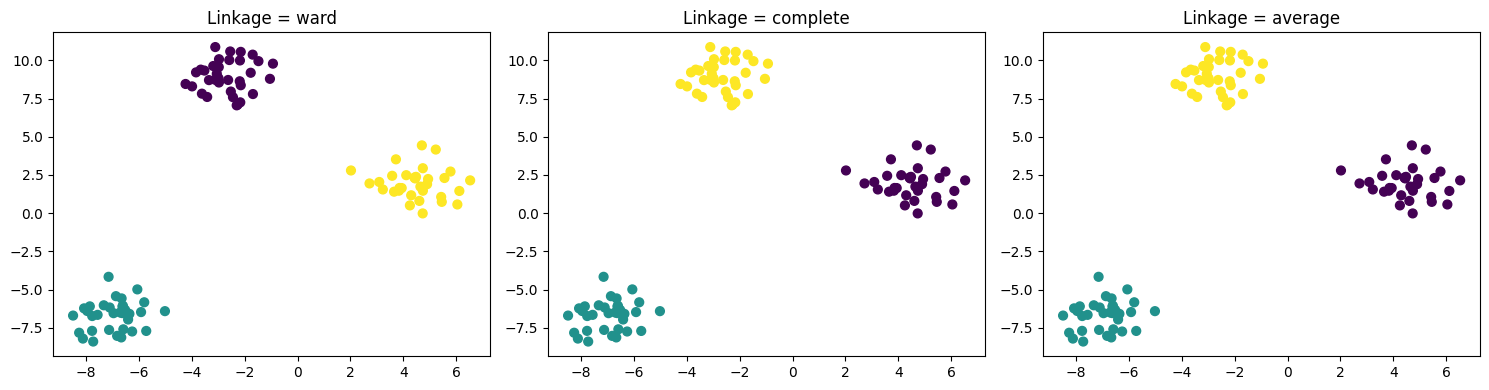

ward: 군집을 합쳤을 때 군집 내 분산의 증가가 가장 작아지는 방향으로 병합한다. 비교적 균형 잡힌 군집을 만드는 경향이 있다.
complete: 두 군집에 속한 데이터들 사이의 최대 거리를 기준으로 군집 간 거리를 계산한다. 군집이 너무 퍼지는 것을 방지하는 경향이 있다.
average: 두 군집에 속한 모든 데이터 쌍의 평균 거리를 기준으로 군집 간 거리를 계산한다. complete보다 완화된 기준으로 병합한다.


In [12]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=100,
    centers=3,
    n_features=2,
    random_state=42
)

linkages = ['ward', 'complete', 'average']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, linkage in zip(axes, linkages):
    agg = AgglomerativeClustering(
        n_clusters=3,
        linkage=linkage
    )

    labels = agg.fit_predict(X)

    ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40)
    ax.set_title(f'Linkage = {linkage}')

plt.tight_layout()
plt.show()

print("ward: 군집을 합쳤을 때 군집 내 분산의 증가가 가장 작아지는 방향으로 병합한다. 비교적 균형 잡힌 군집을 만드는 경향이 있다.")
print("complete: 두 군집에 속한 데이터들 사이의 최대 거리를 기준으로 군집 간 거리를 계산한다. 군집이 너무 퍼지는 것을 방지하는 경향이 있다.")
print("average: 두 군집에 속한 모든 데이터 쌍의 평균 거리를 기준으로 군집 간 거리를 계산한다. complete보다 완화된 기준으로 병합한다.")


#### 문제 7: 고객 세그먼테이션 (RFM 기법)의 개념

고객 세그먼테이션은 마케팅 분야에서 고객을 유사한 특성별로 그룹화하는 데 사용됩니다. 이 중 RFM (Recency, Frequency, Monetary) 기법은 가장 널리 사용되는 방법 중 하나입니다. RFM 각 지표의 의미를 설명하고, 왜 이 세 가지 지표가 고객 가치를 평가하고 세그먼테이션하는 데 효과적인지 간략하게 서술하세요.

**답안**

RFM은 고객의 구매 행동을 세 가지 기준으로 요약하여 고객 가치를 평가하고 세그먼트로 나누는 방법이다.

- **Recency**: 고객이 얼마나 최근에 구매했는지를 의미한다. 기준일로부터 마지막 구매일까지의 일수로 계산하며, 값이 작을수록 최근에 구매한 고객이므로 재구매 가능성이 높다고 볼 수 있다.
- **Frequency**: 고객이 일정 기간 동안 얼마나 자주 구매했는지를 의미한다. 구매 횟수가 많을수록 브랜드나 서비스에 대한 충성도가 높을 가능성이 있다.
- **Monetary**: 고객이 일정 기간 동안 얼마나 많은 금액을 지출했는지를 의미한다. 총 구매 금액이 클수록 기업에 기여한 매출 가치가 높다고 볼 수 있다.

이 세 지표가 효과적인 이유는 고객의 **최근성, 구매 빈도, 구매 규모**를 함께 고려하기 때문이다. 예를 들어 최근에 자주 구매하고 많은 금액을 지출한 고객은 핵심 고객으로 분류할 수 있고, 과거에는 많이 구매했지만 최근 구매가 없는 고객은 재활성화 마케팅 대상이 될 수 있다. 따라서 RFM은 고객별 마케팅 전략을 세우는 데 유용하다.


#### 문제 8: RFM 특징 데이터 전처리 및 생성

주어진 가상의 거래 데이터셋을 사용하여 RFM (Recency, Frequency, Monetary) 특징을 생성하세요. RFM은 고객 세그먼테이션을 위한 핵심 지표입니다. 각 RFM 지표를 계산하고, 최종적으로 고객별 RFM 데이터프레임을 생성하세요.

**데이터셋:** 다음 딕셔너리 형태의 데이터를 사용하여 `DataFrame`을 생성합니다.
```python
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
```

**계산 기준일:** `2023-03-01` (이 날짜를 기준으로 Recency를 계산합니다.)

**RFM 지표 계산:**
1. `PurchaseDate` 컬럼을 `datetime` 타입으로 변환합니다.
2. 각 고객(`CustomerID`)별로 다음 RFM 지표를 계산합니다.
   - **Recency:** `계산 기준일`로부터 가장 '최근' 구매일까지의 일수 (작을수록 좋음)
   - **Frequency:** 일정 기간 동안의 총 구매 '횟수'
   - **Monetary:** 일정 기간 동안의 총 구매 '금액' (Price의 합계)
3. 최종적으로 `CustomerID`, `Recency`, `Frequency`, `Monetary` 컬럼을 포함하는 RFM 데이터프레임을 생성하고 첫 5행을 출력합니다.

In [14]:
import pandas as pd

# 데이터 생성
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}

df = pd.DataFrame(data)

# PurchaseDate 컬럼을 datetime 타입으로 변환
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# 계산 기준일
reference_date = pd.to_datetime('2023-03-01')

# 고객별 RFM 계산
rfm = df.groupby('CustomerID').agg(
    Recency=('PurchaseDate', lambda x: (reference_date - x.max()).days),
    Frequency=('PurchaseDate', 'count'),
    Monetary=('Price', 'sum')
).reset_index()

# 결과 출력
rfm.head()


,CustomerID,Recency,Frequency,Monetary
0,1,28,3,450
1,2,19,2,170
2,3,9,4,630
3,4,24,2,320
4,5,52,2,600
